# ViLT — Visual Question Answering

Notebook gồm:
1. Chuẩn bị dữ liệu và chia Train/Dev/Test theo ảnh.
2. Đánh giá checkpoint ViLT ban đầu.
3. Fine-tune trên Train, chọn checkpoint bằng Dev.
4. Đánh giá trên Test.
5. Demo dự đoán và biểu đồ so sánh.

Kết quả Test sau fine-tune:
- Exact match: 73.22%
- Consensus với chuẩn hóa cơ bản: 82.74%

Không cần chạy lại toàn bộ notebook để xem kết quả đã lưu.

## 1. Kiểm tra môi trường và dữ liệu đầu vào

### 1.1. Liệt kê các input của notebook

Ô code bên dưới kiểm tra các thư mục và file trong `/kaggle/input`.
Đây là nơi Kaggle đặt những dataset và source code đã thêm vào notebook.

Mục đích:
- Kiểm tra các input cần thiết đã được thêm chưa.
- Xem tên thư mục để xác định đường dẫn dùng ở các bước sau.

Kết quả: danh sách tên thư mục và file. Ô này chỉ xem tên,
không đọc toàn bộ dữ liệu, không sửa file và chưa chạy mô hình.


In [2]:
from pathlib import Path

root = Path("/kaggle/input")

for folder in root.iterdir():
    print(f"\nDataset: {folder.name}")
    for item in sorted(folder.iterdir()):
        print("  ", item.name)


Dataset: datasets
   dungnt28
   henrychibueze


### 1.2. Kiểm tra cấu trúc dataset ảnh

Ô code bên dưới xem nội dung dataset `henrychibueze/vqa-dataset`.

Phần đầu liệt kê các thư mục và file trực tiếp bên trong dataset.
Phần sau tìm các file JSON, CSV, TSV hoặc Parquet, kể cả trong thư mục con.

Trong dự án này:
- Dùng ảnh trong thư mục `val2014-resised`.
- Không dùng ba file `vaq2.0.*Images.txt` để tạo dữ liệu cuối cùng.
- Câu hỏi và đáp án được lấy từ hai file JSON VQA v2 đã thêm riêng.

Ô này chỉ kiểm tra cấu trúc file, chưa xử lý dữ liệu.


In [3]:
from pathlib import Path

root = Path("/kaggle/input/datasets/henrychibueze/vqa-dataset")

for item in sorted(root.iterdir()):
    print("[Folder]" if item.is_dir() else "[File]", item.name)

print("\nCác file câu hỏi/đáp án:")
for item in root.rglob("*"):
    if item.is_file() and item.suffix.lower() in {".json", ".csv", ".tsv", ".parquet"}:
        print(item.relative_to(root))

[Folder] val2014-resised
[File] vaq2.0.DevImages.txt
[File] vaq2.0.TestImages.txt
[File] vaq2.0.TrainImages.txt

Các file câu hỏi/đáp án:


### 1.3. Kiểm tra câu hỏi, đáp án và ảnh

Ô code tìm hai file JSON VQA v2 và thư mục `val2014-resised`
trong các input đã thêm vào Kaggle.

Sau đó đọc dữ liệu và kiểm tra số câu hỏi có ảnh tương ứng.
Tên ảnh được xác định từ image_id của câu hỏi.

Kết quả dự kiến:
- 214,354 câu hỏi.
- 214,354 bản ghi đáp án.
- 8,127 ảnh có sẵn.
- 63,916 câu hỏi có ảnh tương ứng.

Chỉ những câu hỏi có ảnh mới được đưa vào dữ liệu của dự án.
Ô này chưa ghép câu hỏi với đáp án và chưa chia Train/Dev/Test.

Nếu không tìm thấy file hoặc tìm thấy nhiều bản cùng tên,
code sẽ dừng để tránh đọc nhầm dữ liệu.

In [5]:
from pathlib import Path
import json

root = Path("/kaggle/input")

def find_file(name):
    paths = list(root.rglob(name))
    if len(paths) != 1:
        raise ValueError(f"Tìm thấy {len(paths)} file tên {name}")
    return paths[0]

question_path = find_file("v2_OpenEnded_mscoco_val2014_questions.json")
annotation_path = find_file("v2_mscoco_val2014_annotations.json")

with question_path.open(encoding="utf-8") as f:
    questions = json.load(f)["questions"]

with annotation_path.open(encoding="utf-8") as f:
    annotations = json.load(f)["annotations"]

image_dirs = [p for p in root.rglob("val2014-resised") if p.is_dir()]
if len(image_dirs) != 1:
    raise ValueError("Không tìm được duy nhất một thư mục ảnh")

image_dir = image_dirs[0]
available_images = {p.name for p in image_dir.glob("*.jpg")}

matched = sum(
    f"COCO_val2014_{q['image_id']:012d}.jpg" in available_images
    for q in questions
)

print("Số câu hỏi:", len(questions))
print("Số bản ghi đáp án:", len(annotations))
print("Số ảnh có sẵn:", len(available_images))
print("Số câu hỏi có ảnh tương ứng:", matched)
print("\nCâu hỏi mẫu:", questions[0])
print("Đáp án mẫu:", annotations[0]["multiple_choice_answer"])

Số câu hỏi: 214354
Số bản ghi đáp án: 214354
Số ảnh có sẵn: 8127
Số câu hỏi có ảnh tương ứng: 63916

Câu hỏi mẫu: {'image_id': 262148, 'question': 'Where is he looking?', 'question_id': 262148000}
Đáp án mẫu: down


### Ghép câu hỏi, đáp án và ảnh

Ghép câu hỏi với bản ghi đáp án bằng question_id, rồi kiểm tra
image_id của hai bản ghi có khớp nhau không.

Chỉ giữ câu hỏi có ảnh và đáp án tương ứng. Mỗi mẫu gồm:
đường dẫn ảnh, câu hỏi, đáp án đại diện và danh sách đáp án
do người gán nhãn cung cấp.

Kết quả dự kiến: 63,916 mẫu ghép thành công, không thiếu đáp án.

Đây là bước khảo sát để hiểu dữ liệu. Script data_prep.py

In [6]:
answer_map = {a["question_id"]: a for a in annotations}

records = []
missing_answers = 0

for q in questions:
    image_name = f"COCO_val2014_{q['image_id']:012d}.jpg"

    if image_name not in available_images:
        continue

    a = answer_map.get(q["question_id"])

    if a is None:
        missing_answers += 1
        continue

    if q["image_id"] != a["image_id"]:
        raise ValueError(f"Image ID không khớp: {q['question_id']}")

    records.append({
        "question_id": q["question_id"],
        "image_id": q["image_id"],
        "image_path": str(image_dir / image_name),
        "question": q["question"],
        "answer": a["multiple_choice_answer"],
        "answers": [item["answer"] for item in a["answers"]],
        "answer_type": a["answer_type"],
    })

from collections import Counter

print("Số mẫu ghép thành công:", len(records))
print("Số câu hỏi thiếu đáp án:", missing_answers)
print("Loại đáp án:", dict(Counter(r["answer_type"] for r in records)))

print("\n3 mẫu đầu:")
for r in records[:3]:
    print("Question:", r["question"])
    print("Answer:", r["answer"])
    print()

Số mẫu ghép thành công: 63916
Số câu hỏi thiếu đáp án: 0
Loại đáp án: {'other': 27733, 'yes/no': 28908, 'number': 7275}

3 mẫu đầu:
Question: What website copyrighted the picture?
Answer: foodiebakercom

Question: Is this a creamy soup?
Answer: no

Question: Is this rice noodle soup?
Answer: yes



## 2. Chuẩn bị dữ liệu

### 2.1. Chạy script data_prep.py

Ô code tìm file data_prep.py trong các input của Kaggle và chạy script.

Script thực hiện:
- Ghép câu hỏi với đáp án bằng question_id.
- Chỉ giữ những câu hỏi có ảnh tương ứng.
- Chia Train/Dev/Test theo image_id để các tập không dùng chung ảnh.
- Gán nhóm câu hỏi bằng quy tắc từ khóa.

Seed 42 giúp tái tạo cách chia tập khi dùng cùng dữ liệu đầu vào.
Tỉ lệ 80%/10%/10% áp dụng cho số ảnh, không phải số câu hỏi.

Kết quả dự kiến:
- Train: 51,107 câu hỏi, 6,501 ảnh.
- Dev: 6,684 câu hỏi, 812 ảnh.
- Test: 6,125 câu hỏi, 814 ảnh.

Các file JSONL và thông tin xử lý được lưu tại:
`/kaggle/working/vqa_processed`

Ô này chuẩn bị dữ liệu, chưa train mô hình.

In [7]:
from pathlib import Path
import subprocess
import sys

paths = list(Path("/kaggle/input").rglob("data_prep.py"))

if len(paths) != 1:
    raise ValueError(f"Tìm thấy {len(paths)} file data_prep.py")

subprocess.run(
    [
        sys.executable,
        str(paths[0]),
        "--raw-dir", "/kaggle/input",
        "--output-dir", "/kaggle/working/vqa_processed",
        "--seed", "42",
    ],
    check=True,
)

train: 51107 questions, 6501 images
  Categories: {'counting': 5004, 'color': 4528, 'spatial': 1012, 'reasoning': 389, 'object': 1483, 'other': 38691}
dev: 6684 questions, 812 images
  Categories: {'counting': 614, 'color': 639, 'spatial': 137, 'reasoning': 52, 'object': 236, 'other': 5006}
test: 6125 questions, 814 images
  Categories: {'counting': 580, 'color': 550, 'spatial': 101, 'reasoning': 44, 'object': 199, 'other': 4651}
Prepared files saved to: /kaggle/working/vqa_processed


CompletedProcess(args=['/usr/bin/python3', '/kaggle/input/datasets/dungnt28/data-preparation/data_prep.py', '--raw-dir', '/kaggle/input', '--output-dir', '/kaggle/working/vqa_processed', '--seed', '42'], returncode=0)

### Cài thư viện Transformers

Cài Transformers phiên bản 4.57.6 để tải và sử dụng mô hình ViLT,
đồng thời xử lý ảnh và câu hỏi thành đầu vào cho mô hình.

In [8]:
!pip install -q "transformers==4.57.6"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 101.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 88.8 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


### Kiểm tra thư viện ViLT

Import bộ xử lý đầu vào ViltProcessor và cấu hình ViltConfig
để kiểm tra thư viện đã sẵn sàng sử dụng.

Ô này in phiên bản Transformers và thông báo import thành công.
Chưa tải trọng số mô hình và chưa train.

In [9]:
import transformers
from transformers import ViltProcessor, ViltConfig

print("Transformers:", transformers.__version__)
print("Import ViLT thành công")

Transformers: 4.57.6
Import ViLT thành công


### 2.2. Kiểm tra dữ liệu đầu vào cho ViLT

Ô này tải code trong dataset.py, bộ xử lý và cấu hình của ViLT,
sau đó đọc file train.jsonl đã tạo.( train.jsonl: dữ liệu Train do
data_prep.py tạo, mỗi dòng chứa một mẫu ảnh–câu hỏi–đáp án.)

DataLoader lấy thử 2 mẫu. VQACollator xử lý ảnh, câu hỏi và đáp án,
rồi ghép chúng thành một batch để đưa vào mô hình.

Kết quả gồm:
- Số mẫu Train: dự kiến 51,107.
- Kích thước tensor ảnh, câu hỏi và nhãn đáp án.
- Mỗi mẫu có đáp án thuộc từ vựng của mô hình hay không.

Tensor là dữ liệu dạng mảng số mà mô hình sử dụng.
Batch là một nhóm mẫu được xử lý cùng lúc.

Giá trị False nghĩa là mẫu không có đáp án phù hợp với từ vựng
của checkpoint, không có nghĩa là ảnh hoặc câu hỏi bị lỗi.
Các mẫu này sẽ được loại khỏi Train trong script training.

Ô này chỉ kiểm tra 2 mẫu, chưa tải trọng số ViLT và chưa train.

In [10]:
from pathlib import Path
import importlib.util

from transformers import ViltProcessor, ViltConfig
from torch.utils.data import DataLoader

paths = list(Path("/kaggle/input").rglob("dataset.py"))
if len(paths) != 1:
    raise ValueError(f"Tìm thấy {len(paths)} file dataset.py")

spec = importlib.util.spec_from_file_location("vqa_dataset", paths[0])
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

checkpoint = "dandelin/vilt-b32-finetuned-vqa"
processor = ViltProcessor.from_pretrained(checkpoint)
config = ViltConfig.from_pretrained(checkpoint)

train_dataset = module.VQADataset(
    "/kaggle/working/vqa_processed/train.jsonl"
)

loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=module.VQACollator(processor, config.label2id),
)

batch = next(iter(loader))

print("Số mẫu Train:", len(train_dataset))

for name, tensor in batch["inputs"].items():
    print(name, tuple(tensor.shape))

print("Có đáp án trong từ vựng:", batch["has_supported_answer"].tolist())

Số mẫu Train: 51107
pixel_values (2, 3, 384, 384)
pixel_mask (2, 384, 384)
input_ids (2, 9)
token_type_ids (2, 9)
attention_mask (2, 9)
labels (2, 3129)
Có đáp án trong từ vựng: [False, True]


### 2.3. Kiểm tra đáp án ngoài từ vựng

Checkpoint ViLT sử dụng một bộ từ vựng cố định gồm 3,129 đáp án.
Ô này kiểm tra từng mẫu trong Train, Dev và Test có ít nhất
một đáp án của người gán nhãn nằm trong bộ từ vựng đó hay không.

Đáp án được chuyển thành chữ thường và chuẩn hóa khoảng trắng
trước khi so sánh.

Kết quả dự kiến:
- Train: 688/51,107 mẫu không có đáp án phù hợp (1.35%).
- Dev: 92/6,684 mẫu (1.38%).
- Test: 108/6,125 mẫu (1.76%).

Script train.py loại 688 mẫu này khỏi Train, còn 50,419 mẫu.
Dev và Test vẫn giữ đầy đủ để đánh giá trên cùng dữ liệu.

Ô này chỉ thống kê, không xóa mẫu và không thay đổi file dữ liệu.
Danh sách đáp án ngoài từ vựng giúp giải thích một hạn chế của mô hình.

In [11]:
from collections import Counter

supported_answers = {
    module.answer_key(a)
    for a in config.label2id
}

for split in ["train", "dev", "test"]:
    dataset = module.VQADataset(
        f"/kaggle/working/vqa_processed/{split}.jsonl"
    )

    unsupported = []

    for record in dataset.records:
        answers = {
            module.answer_key(a)
            for a in record["answers"]
        }

        if not answers & supported_answers:
            unsupported.append(record)

    total = len(dataset)

    print(
        f"{split}: {len(unsupported)}/{total} mẫu không có "
        f"đáp án phù hợp ({len(unsupported) / total:.2%})"
    )

    if split == "train":
        counts = Counter(
            module.answer_key(a)
            for r in unsupported
            for a in r["answers"]
        )
        print(
            "Đáp án ngoài từ vựng phổ biến:",
            counts.most_common(10)
        )

train: 688/51107 mẫu không có đáp án phù hợp (1.35%)
Đáp án ngoài từ vựng phổ biến: [('508', 60), ('bieber', 46), ('date street', 44), ('213', 40), ('370', 39), ('86902', 30), ('django', 29), ('208', 29), ('back to future', 28), ('rocker', 28)]
dev: 92/6684 mẫu không có đáp án phù hợp (1.38%)
test: 108/6125 mẫu không có đáp án phù hợp (1.76%)


## 3. Kiểm tra và đánh giá mô hình ban đầu
### Kiểm tra GPU
Ô này kiểm tra PyTorch có sử dụng được GPU hay không
và in tên GPU nếu có.
- True: GPU đã sẵn sàng.
- False: phiên hiện tại chưa sử dụng được GPU.
- 
Ô code chỉ kiểm tra, không tự bật GPU.
Để bật, chọn GPU accelerator trong Settings của notebook.

Thí nghiệm của nhóm đã chạy trên GPU Tesla T4.
GPU giúp tăng tốc quá trình train và dự đoán.

In [12]:
import torch

print("GPU khả dụng:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU khả dụng: True
GPU: Tesla T4


### 3.1. Dự đoán thử bằng ViLT trên GPU

Ô này đọc dataset.py và model.py từ các input của Kaggle,
sau đó tải checkpoint ViLT ban đầu lên GPU.

Checkpoint đã được tác giả fine-tune trên VQAv2,
chưa được train thêm bằng dữ liệu của nhóm.

Lấy 2 mẫu đầu của Train, xử lý ảnh và câu hỏi thành một batch,
rồi dự đoán đáp án. Nhãn đáp án không được đưa vào mô hình.

Kết quả hiển thị:
- Thiết bị mô hình: dự kiến cuda:0.
- Câu hỏi, đáp án dữ liệu và đáp án ViLT dự đoán.

Sau khi hiển thị dự đoán, giải phóng mô hình thử khỏi bộ nhớ GPU
để dành bộ nhớ cho đánh giá và training. Checkpoint trên ổ đĩa
không bị xóa; ô demo phía sau sẽ tải lại mô hình khi cần.

Nếu GPU chưa sẵn sàng, code dừng và báo lỗi.
Ô này chỉ kiểm tra dự đoán, không train và chưa đánh giá toàn bộ Test.

In [13]:
from pathlib import Path
import importlib.util
import torch
from torch.utils.data import DataLoader

def load_python_file(filename, module_name):
    paths = list(Path("/kaggle/input").rglob(filename))
    if len(paths) != 1:
        raise ValueError(f"Tìm thấy {len(paths)} file {filename}")

    spec = importlib.util.spec_from_file_location(module_name, paths[0])
    loaded = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(loaded)
    return loaded

dataset_module = load_python_file("dataset.py", "vqa_dataset")
model_module = load_python_file("model.py", "vqa_model")

if not torch.cuda.is_available():
    raise RuntimeError("Phiên hiện chưa có GPU")

processor, model = model_module.load_model(device="cuda")

train_dataset = dataset_module.VQADataset(
    "/kaggle/working/vqa_processed/train.jsonl"
)

collator = dataset_module.VQACollator(
    processor, model.config.label2id
)

loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collator,
)

batch = next(iter(loader))
inputs = {
    name: tensor.to("cuda")
    for name, tensor in batch["inputs"].items()
    if name != "labels"
}

with torch.no_grad():
    predicted_ids = model(**inputs).logits.argmax(dim=-1).tolist()

print("Thiết bị mô hình:", next(model.parameters()).device)

for record, answer_id in zip(batch["metadata"], predicted_ids):
    print("\nCâu hỏi:", record["question"])
    print("Đáp án dữ liệu:", record["answer"])
    print("ViLT dự đoán:", model.config.id2label[answer_id])
    
# Giải phóng mô hình thử trước khi chạy đánh giá và training
del model, inputs

import gc
gc.collect()
torch.cuda.empty_cache()    

Thiết bị mô hình: cuda:0

Câu hỏi: What website copyrighted the picture?
Đáp án dữ liệu: foodiebakercom
ViLT dự đoán: unknown

Câu hỏi: Is this a creamy soup?
Đáp án dữ liệu: no
ViLT dự đoán: no


### Kiểm tra các file dữ liệu đã tạo

Kiểm tra train.jsonl, dev.jsonl và test.jsonl trong
`/kaggle/working/vqa_processed`.

Cả ba file cần hiển thị “Có” trước khi tiếp tục.
Nếu hiển thị “Chưa có”, hãy chạy ô chuẩn bị dữ liệu 2.1.

Ô này chỉ kiểm tra file tồn tại.

In [14]:
from pathlib import Path

root = Path("/kaggle/working/vqa_processed")

for split in ["train", "dev", "test"]:
    path = root / f"{split}.jsonl"
    print(path.name, "Có" if path.exists() else "Chưa có")

train.jsonl Có
dev.jsonl Có
test.jsonl Có


### 3.2. Đánh giá mô hình ban đầu trên tập Test

Chạy evaluate.py để đánh giá checkpoint ViLT ban đầu trên toàn bộ
6,125 câu hỏi Test. Đây là kết quả baseline dùng để so sánh
với mô hình sau khi nhóm fine-tune.

Nếu test.jsonl chưa tồn tại, code chạy lại script chuẩn bị dữ liệu.
Đánh giá sử dụng GPU và batch size 8, tức xử lý 8 mẫu mỗi batch.

Script tính kết quả tổng thể và theo nhóm câu hỏi:
- Exact match: dự đoán khớp với đáp án đại diện của dữ liệu.
- Consensus: chấm điểm theo mức đồng thuận của các đáp án
  do người gán nhãn cung cấp.

Cả hai dùng chuẩn hóa chữ thường và khoảng trắng,
chưa áp dụng toàn bộ quy tắc chuẩn hóa VQA chính thức.

Kết quả baseline:
- Exact match: 72.88%.
- Consensus: 82.50%.

Metrics và dự đoán được lưu tại:
`/kaggle/working/results/baseline`

Ô này chỉ đánh giá, không cập nhật trọng số mô hình.

In [15]:
from pathlib import Path
import subprocess
import sys

root = Path("/kaggle/input")

def find_script(name):
    paths = list(root.rglob(name))
    if len(paths) != 1:
        raise ValueError(f"Tìm thấy {len(paths)} file {name}")
    return paths[0]

# Tạo lại dữ liệu nếu lần thêm Input làm phiên khởi động lại
if not Path("/kaggle/working/vqa_processed/test.jsonl").exists():
    prep_paths = list(root.rglob("data_preparation.py"))
    prep = prep_paths[0] if len(prep_paths) == 1 else find_script("data_prep.py")

    subprocess.run(
        [
            sys.executable, str(prep),
            "--raw-dir", "/kaggle/input",
            "--output-dir", "/kaggle/working/vqa_processed",
        ],
        check=True,
    )

subprocess.run(
    [
        sys.executable,
        str(find_script("evaluate.py")),
        "--device", "cuda",
        "--batch-size", "8",
        "--output-dir", "/kaggle/working/results/baseline",
    ],
    check=True,
)

Device: cuda:0; evaluation examples: 6125


Evaluation: 100%|██████████| 766/766 [02:20<00:00,  5.44it/s]


overall: n=6125, exact=72.88%, consensus=82.50%
counting: n=580, exact=56.90%, consensus=69.22%
color: n=550, exact=78.55%, consensus=87.47%
spatial: n=101, exact=50.50%, consensus=63.47%
reasoning: n=44, exact=40.91%, consensus=47.27%
object: n=199, exact=67.84%, consensus=76.63%
other: n=4651, exact=75.21%, consensus=84.56%
Results saved to: /kaggle/working/results/baseline


CompletedProcess(args=['/usr/bin/python3', '/kaggle/input/datasets/dungnt28/evaluate/evaluate.py', '--device', 'cuda', '--batch-size', '8', '--output-dir', '/kaggle/working/results/baseline'], returncode=0)

### 3.3. Nén kết quả baseline để lưu và chia sẻ

Nén thư mục kết quả đánh giá mô hình ban đầu thành
`/kaggle/working/baseline_results.zip`.

File ZIP chứa metrics và dự đoán, không chứa trọng số mô hình
hay toàn bộ ảnh của dataset.

Sau khi Save Version với lưu output được bật,
tải file từ tab Output của bản đã lưu.
Link hiển thị dưới ô code có thể không tải được.



In [16]:
import shutil
from IPython.display import FileLink, display

shutil.make_archive(
    "/kaggle/working/baseline_results",
    "zip",
    "/kaggle/working/results/baseline",
)

display(FileLink("/kaggle/working/baseline_results.zip"))

/kaggle/working/baseline_results.zip

## 4. Fine-tune ViLT

### 4.1. Chạy thử training trên dữ liệu nhỏ

Kiểm tra cú pháp và chạy bản train.py đầy đủ tại input training-codepy.

Chạy thử 1 epoch với 128 mẫu Train và 64 mẫu Dev.
Batch size là 4, tích lũy gradient qua 4 batch trước mỗi lần
cập nhật trọng số khi đủ batch.

Mục đích là kiểm tra quy trình đọc dữ liệu, cập nhật trọng số,
đánh giá Dev và lưu checkpoint trước khi train toàn bộ.

Kết quả lưu tại `/kaggle/working/vilt_smoke_test`.
Đây là lần chạy kiểm tra, không dùng làm kết quả thí nghiệm chính.

Đây là smoke test, tức lần chạy nhỏ để kiểm tra quy trình.
Kết quả này không dùng làm kết quả thí nghiệm chính.
Chỉ tiếp tục train toàn bộ sau khi thấy log training,
đánh giá Dev và thông báo lưu checkpoint thành công.

In [17]:
import ast
import subprocess
import sys
from pathlib import Path

path = Path("/kaggle/input/datasets/dungnt28/training-codepy/train.py")
ast.parse(path.read_text(encoding="utf-8"))

subprocess.run(
    [
        sys.executable, str(path),
        "--epochs", "1",
        "--batch-size", "4",
        "--accumulation-steps", "4",
        "--limit-train", "128",
        "--limit-dev", "64",
        "--output-dir", "/kaggle/working/vilt_smoke_test",
    ],
    check=True,
)

Train: 128; Dev: 64; excluded unsupported Train: 688


Development evaluation: 100%|██████████| 16/16 [00:01<00:00, 11.37it/s]


{"epoch": 1, "train_loss": 2.6899568680673838, "dev_exact_match_basic_pct": 68.75, "dev_consensus_basic_pct": 75.78125}
Best checkpoint saved: /kaggle/working/vilt_smoke_test/best
Training complete. Test data was not used for selection.


CompletedProcess(args=['/usr/bin/python3', '/kaggle/input/datasets/dungnt28/training-codepy/train.py', '--epochs', '1', '--batch-size', '4', '--accumulation-steps', '4', '--limit-train', '128', '--limit-dev', '64', '--output-dir', '/kaggle/working/vilt_smoke_test'], returncode=0)

### 4.2. Fine-tune ViLT trên toàn bộ dữ liệu Train

Chạy train.py để cập nhật trọng số của checkpoint ViLT ban đầu
bằng dữ liệu của nhóm.

Thiết lập:
- Train: 50,419 mẫu sau khi loại 688 mẫu ngoài từ vựng đáp án.
- Dev: giữ đủ 6,684 mẫu.
- Epoch: 1 lượt qua tập Train.
- Batch size: 4 mẫu mỗi batch.
- Accumulation steps: 4, tương đương 16 mẫu mỗi lần cập nhật
  khi đủ batch.
- Learning rate: 0.00002, điều chỉnh mức thay đổi trọng số.
- Seed: 42 để kiểm soát các nguồn ngẫu nhiên được thiết lập.

Sau mỗi epoch, đánh giá trên Dev và lưu checkpoint có điểm
Dev consensus cao nhất. Test không được dùng để chọn checkpoint.

Kết quả được lưu tại `/kaggle/working/vilt_finetuned`:
- best/: checkpoint được chọn và bộ xử lý đầu vào.
- training_config.json: cấu hình lần chạy.
- training_history.json: loss và kết quả Dev.

Lần chạy của nhóm mất khoảng 43 phút train và 2 phút đánh giá Dev.
Đây là training chính.

In [18]:
from pathlib import Path
import ast
import subprocess
import sys

# Dùng đúng bản train.py đã chạy smoke test thành công
train_script = Path(
    "/kaggle/input/datasets/dungnt28/training-codepy/train.py"
)

if not train_script.is_file():
    raise FileNotFoundError(f"Không tìm thấy: {train_script}")

# Kiểm tra cú pháp trước khi chạy
ast.parse(train_script.read_text(encoding="utf-8"))

subprocess.run(
    [
        sys.executable, str(train_script),
        "--epochs", "1",
        "--batch-size", "4",
        "--accumulation-steps", "4",
        "--learning-rate", "2e-5",
        "--seed", "42",
        "--output-dir", "/kaggle/working/vilt_finetuned",
    ],
    check=True,
)

Train: 50419; Dev: 6684; excluded unsupported Train: 688


Development evaluation: 100%|██████████| 1671/1671 [02:47<00:00,  9.95it/s]


{"epoch": 1, "train_loss": 2.287594571245625, "dev_exact_match_basic_pct": 72.80071813285458, "dev_consensus_basic_pct": 82.3114901256739}
Best checkpoint saved: /kaggle/working/vilt_finetuned/best
Training complete. Test data was not used for selection.


CompletedProcess(args=['/usr/bin/python3', '/kaggle/input/datasets/dungnt28/training-codepy/train.py', '--epochs', '1', '--batch-size', '4', '--accumulation-steps', '4', '--learning-rate', '2e-5', '--seed', '42', '--output-dir', '/kaggle/working/vilt_finetuned'], returncode=0)

### 4.3. Kiểm tra cấu hình, lịch sử training và checkpoint

Ô này đọc các file được tạo sau bước fine-tune:
- training_config.json: cấu hình và thông tin lần chạy.
- training_history.json: loss Train và điểm đánh giá Dev theo epoch.
- best/: các file mô hình và bộ xử lý đã lưu.

Mục đích là xác nhận training có tạo kết quả thực tế,
không chỉ dựa vào thông báo chương trình kết thúc thành công.

Nếu xuất hiện “Chưa có file” hoặc “Chưa có”,
cần kiểm tra lại log training và đường dẫn lưu kết quả.



In [19]:
from pathlib import Path
import json

root = Path("/kaggle/working/vilt_finetuned")

for name in ["training_config.json", "training_history.json"]:
    path = root / name
    print(f"\n--- {name} ---")

    if path.exists():
        print(json.dumps(json.loads(path.read_text()), indent=2))
    else:
        print("Chưa có file")

print("\nCheckpoint:")
best = root / "best"
print([p.name for p in best.iterdir()] if best.exists() else "Chưa có")


--- training_config.json ---
{
  "model": "dandelin/vilt-b32-finetuned-vqa",
  "data_dir": "/kaggle/working/vqa_processed",
  "output_dir": "/kaggle/working/vilt_finetuned",
  "epochs": 1,
  "batch_size": 4,
  "accumulation_steps": 4,
  "learning_rate": 2e-05,
  "seed": 42,
  "limit_train": 0,
  "limit_dev": 0,
  "original_train_examples": 51107,
  "excluded_unsupported_train_examples": 688,
  "used_train_examples": 50419,
  "used_dev_examples": 6684,
  "partial_run": false,
  "torch_version": "2.11.0+cu128",
  "transformers_version": "4.57.6",
  "selection_metric": "dev consensus with lowercase/whitespace matching",
  "model_revision": "d0a1f6ab88522427a7ae76ceb6e1e1e7b68a1d08"
}

--- training_history.json ---
[
  {
    "epoch": 1,
    "train_loss": 2.287594571245625,
    "dev_exact_match_basic_pct": 72.80071813285458,
    "dev_consensus_basic_pct": 82.3114901256739
  }
]

Checkpoint:
['model.safetensors', 'config.json', 'tokenizer.json', 'preprocessor_config.json', 'vocab.txt', 'spe

## 5. Đánh giá mô hình sau fine-tune

### 5.1. Đánh giá Run A trên Test

Run A là thí nghiệm chính: 1 epoch, learning rate 2e-5.
Checkpoint tốt nhất theo điểm Dev được lưu tại
`/kaggle/working/vilt_finetuned/best`.

Đánh giá trên toàn bộ 6.125 câu hỏi Test, dùng cùng dữ liệu và
cách tính điểm với baseline. Chạy trên GPU với batch size 8.

Kết quả Run A:
- Exact Match: 73,22%.
- Consensus: 82,74%.

Các chỉ số chỉ chuẩn hóa chữ thường và khoảng trắng,
chưa áp dụng toàn bộ quy tắc chuẩn hóa VQA chính thức.

Metrics và dự đoán được lưu tại:
`/kaggle/working/results/finetuned`.


In [20]:
from pathlib import Path
import subprocess
import sys

paths = list(Path("/kaggle/input").rglob("evaluate.py"))
if len(paths) != 1:
    raise ValueError(f"Tìm thấy {len(paths)} file evaluate.py")

subprocess.run(
    [
        sys.executable, str(paths[0]),
        "--model", "/kaggle/working/vilt_finetuned/best",
        "--data-file", "/kaggle/working/vqa_processed/test.jsonl",
        "--device", "cuda",
        "--batch-size", "8",
        "--output-dir", "/kaggle/working/results/finetuned",
    ],
    check=True,
)

Device: cuda:0; evaluation examples: 6125


Evaluation: 100%|██████████| 766/766 [02:01<00:00,  6.30it/s]


overall: n=6125, exact=73.22%, consensus=82.74%
counting: n=580, exact=59.48%, consensus=70.98%
color: n=550, exact=79.45%, consensus=88.60%
spatial: n=101, exact=53.47%, consensus=66.93%
reasoning: n=44, exact=38.64%, consensus=43.86%
object: n=199, exact=66.83%, consensus=74.52%
other: n=4651, exact=75.23%, consensus=84.58%
Results saved to: /kaggle/working/results/finetuned


CompletedProcess(args=['/usr/bin/python3', '/kaggle/input/datasets/dungnt28/evaluate/evaluate.py', '--model', '/kaggle/working/vilt_finetuned/best', '--data-file', '/kaggle/working/vqa_processed/test.jsonl', '--device', 'cuda', '--batch-size', '8', '--output-dir', '/kaggle/working/results/finetuned'], returncode=0)

## 6. Demo và biểu đồ kết quả

### 6.1. Minh họa dự đoán của Run A

Sử dụng checkpoint Run A tại
`/kaggle/working/vilt_finetuned/best`
và lấy 3 mẫu đầu tiên trong tập Test.

Mỗi mẫu hiển thị ảnh, câu hỏi, dự đoán của ViLT
và danh sách đáp án tham khảo từ người gán nhãn.

Ảnh và câu hỏi được chuyển thành tensor; câu hỏi giới hạn
ở 40 token. Mô hình chọn đáp án có điểm cao nhất.

Dùng GPU nếu có, nếu không thì dùng CPU.
Ô này chỉ dự đoán, không cập nhật trọng số.

Ba ví dụ chỉ mang tính minh họa. Kết quả đánh giá toàn bộ
Test của Run A được trình bày ở mục 5.1.

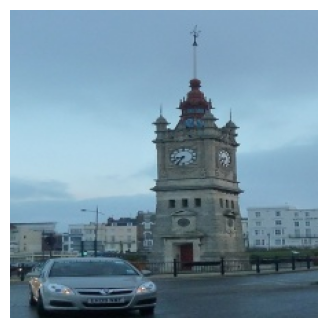

Câu hỏi: Are there any tour buses?
ViLT trả lời: no
Đáp án tham khảo: ['no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no']



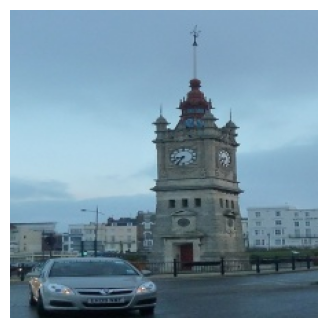

Câu hỏi: What's the statue of?
ViLT trả lời: clock tower
Đáp án tham khảo: ['clock tower', 'nothing', 'tower', 'person', 'tower', 'clock tower', 'clock building', 'tower', 'clock tower', 'clock tower']



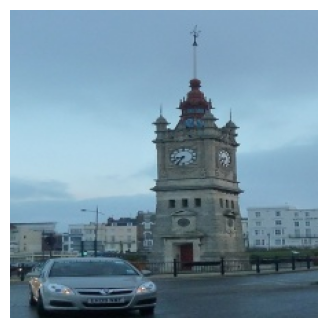

Câu hỏi: Are all three cars facing the same direction?
ViLT trả lời: yes
Đáp án tham khảo: ['no', 'no', 'no', 'no', 'yes', 'no', 'yes', 'yes', 'no', 'no']



In [21]:
import json
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import ViltProcessor, ViltForQuestionAnswering

# Tải mô hình đã fine-tune
checkpoint = "/kaggle/working/vilt_finetuned/best"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = ViltProcessor.from_pretrained(checkpoint)
model = ViltForQuestionAnswering.from_pretrained(checkpoint)
model.to(device)
model.eval()

# Lấy 3 mẫu từ tập Test
test_file = Path("/kaggle/working/vqa_processed/test.jsonl")

with test_file.open(encoding="utf-8") as f:
    examples = [json.loads(line) for line in f][:3]

# Dự đoán và hiển thị từng mẫu
for example in examples:
    image = Image.open(example["image_path"]).convert("RGB")
    question = example["question"]

    inputs = processor(
        images=image,
        text=question,
        padding=True,
        truncation=True,
        max_length=40,
        return_tensors="pt"
    ).to(device)

    with torch.inference_mode():
        predicted_id = model(**inputs).logits.argmax(-1).item()

    prediction = model.config.id2label[predicted_id]

    plt.figure(figsize=(6, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Câu hỏi:", question)
    print("ViLT trả lời:", prediction)
    print("Đáp án tham khảo:", example["answers"])
    print()

### Demo theo 5 nhóm câu hỏi

Hiển thị một mẫu Test của mỗi nhóm: Counting, Color, Spatial,
Reasoning và Object, gồm ảnh, câu hỏi, dự đoán và đáp án tham khảo.

Chạy ô 6.1 trước để tải mô hình. Ô này dùng lại mô hình đã tải.

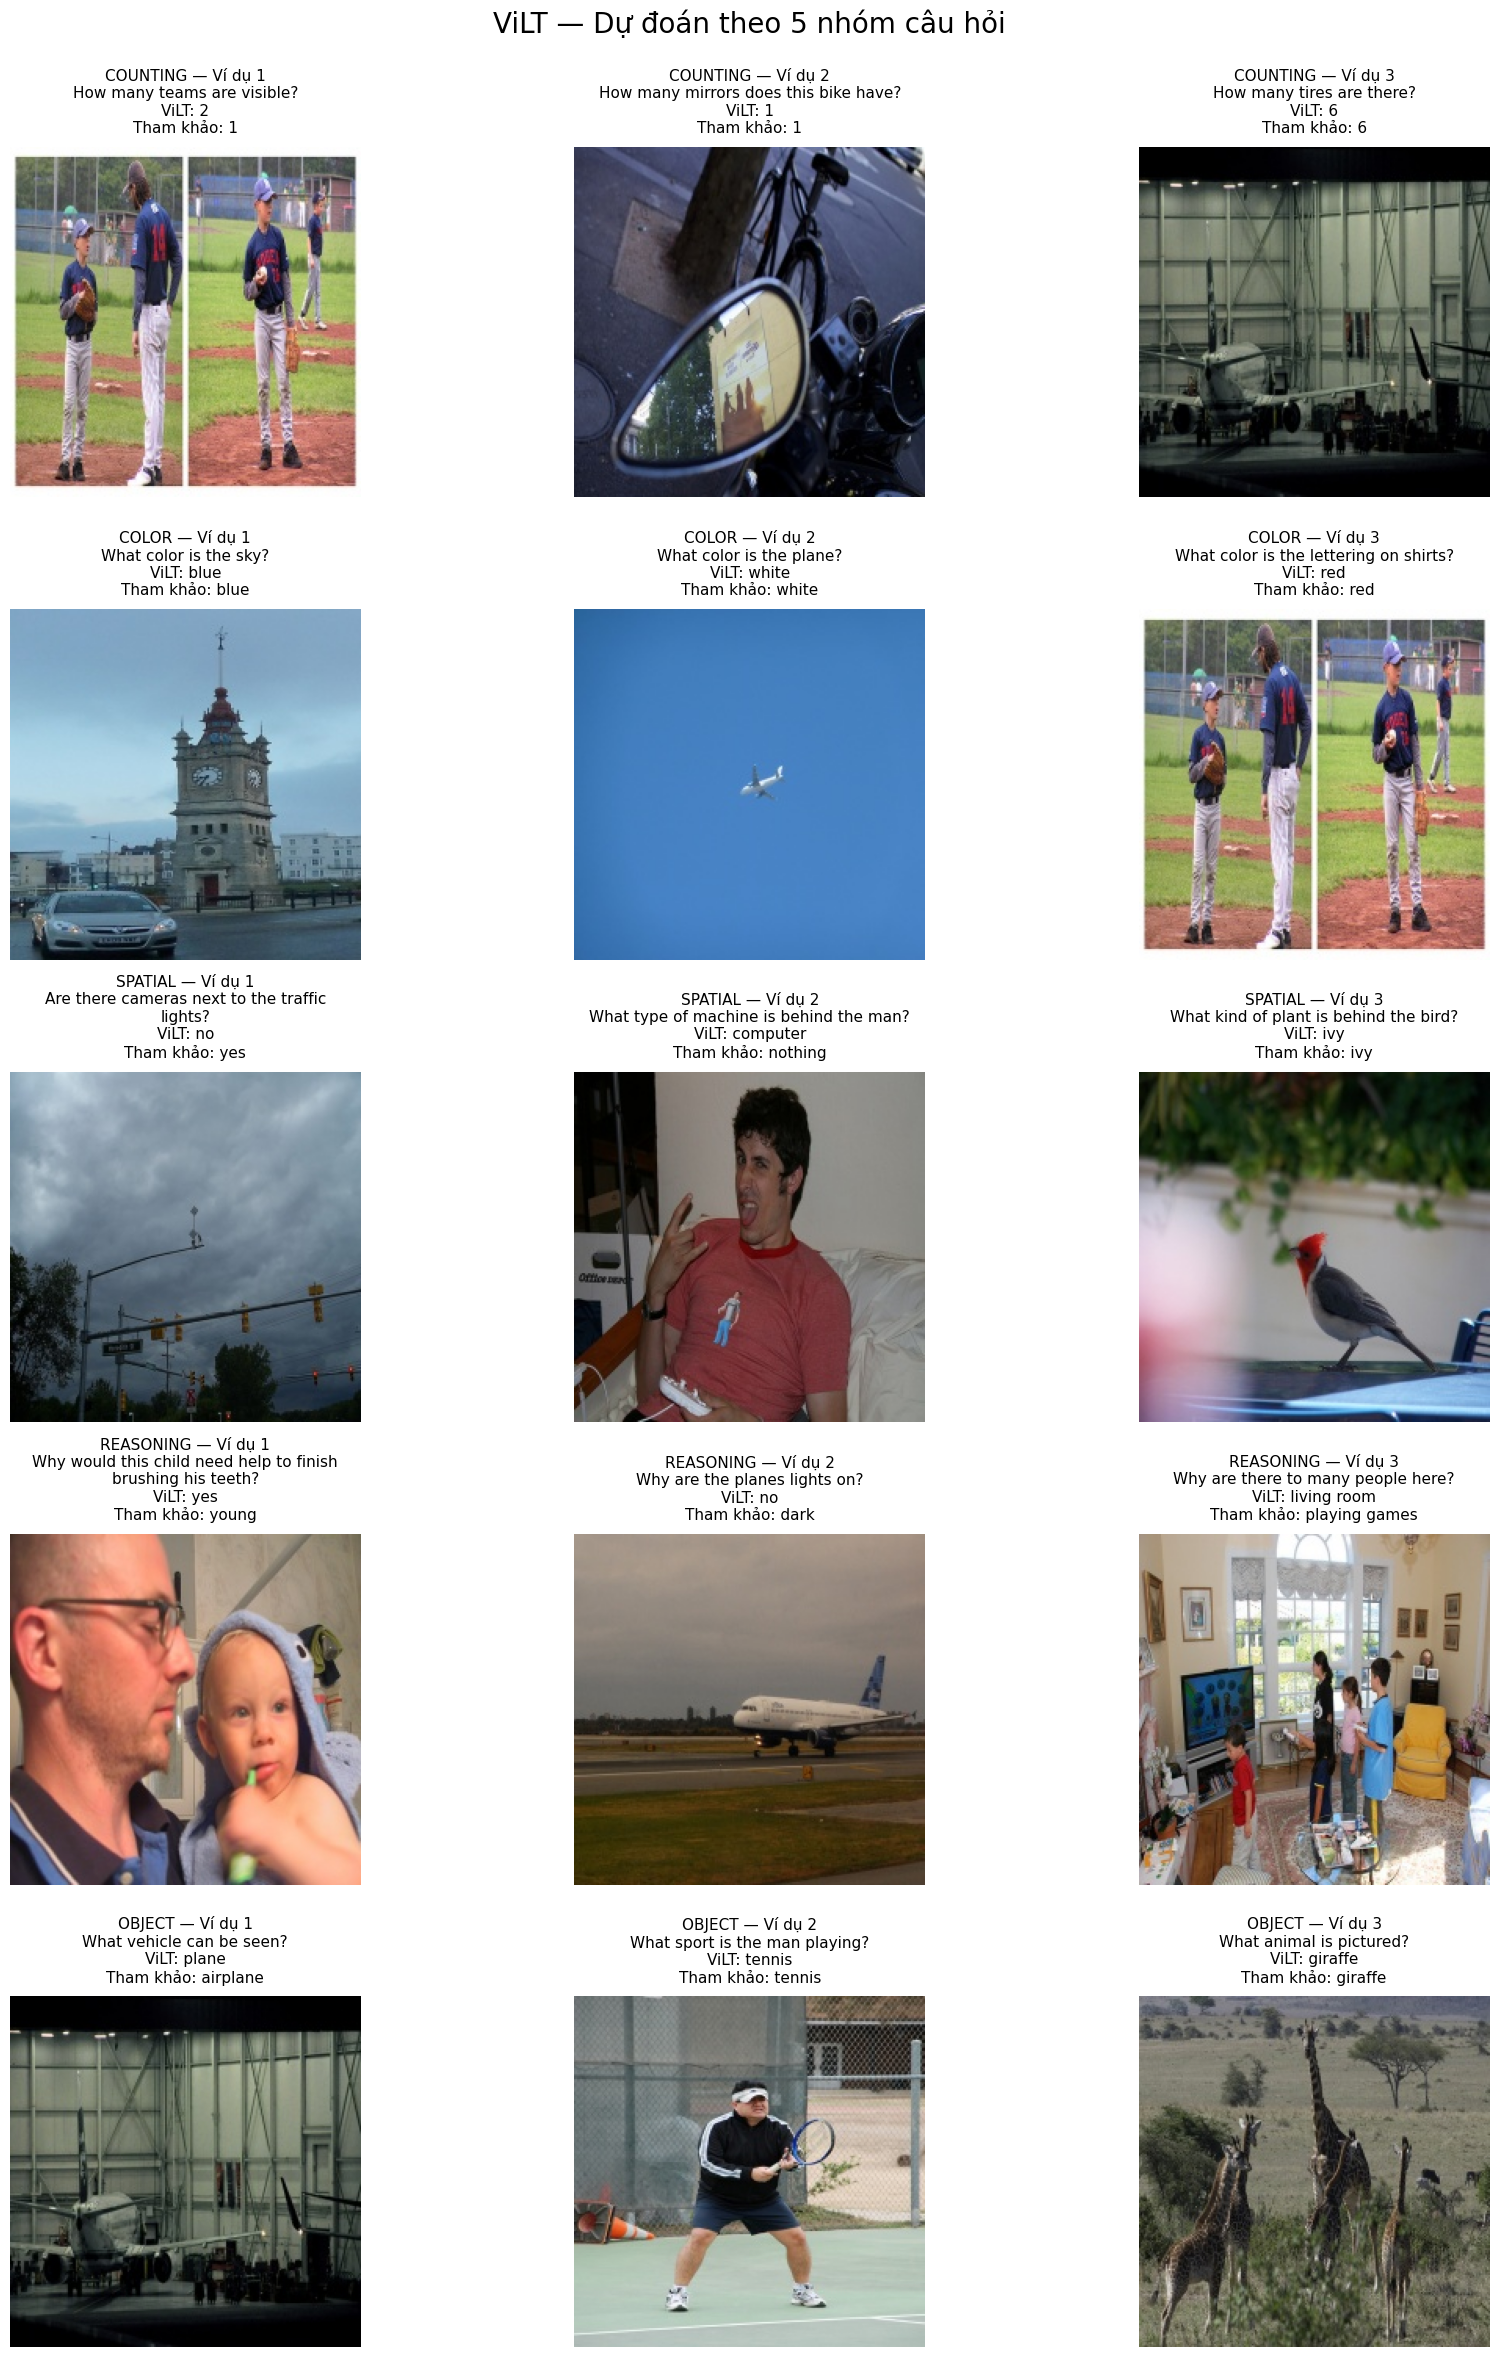

In [22]:
import json
import textwrap
import matplotlib.pyplot as plt
from PIL import Image
import torch

categories = ["counting", "color", "spatial", "reasoning", "object"]
samples_per_category = 3

selected = {category: [] for category in categories}
seen_images = {category: set() for category in categories}

# Chọn 3 ảnh khác nhau trong mỗi nhóm
with open(
    "/kaggle/working/vqa_processed/test.jsonl",
    encoding="utf-8"
) as f:
    for line in f:
        record = json.loads(line)
        category = record["category"]

        if category not in selected:
            continue

        if len(selected[category]) >= samples_per_category:
            continue

        if record["image_id"] in seen_images[category]:
            continue

        selected[category].append(record)
        seen_images[category].add(record["image_id"])

        if all(
            len(rows) == samples_per_category
            for rows in selected.values()
        ):
            break

fig, axes = plt.subplots(
    len(categories),
    samples_per_category,
    figsize=(18, 24),
    squeeze=False
)

for ax in axes.flat:
    ax.axis("off")

model.eval()

# Dự đoán từng nhóm để tiết kiệm bộ nhớ GPU
for row_index, category in enumerate(categories):
    records = selected[category]

    if not records:
        axes[row_index, 0].set_title(f"{category}: không có mẫu")
        continue

    images = []
    for record in records:
        with Image.open(record["image_path"]) as source:
            images.append(source.convert("RGB"))

    inputs = processor(
        images=images,
        text=[record["question"] for record in records],
        padding=True,
        truncation=True,
        max_length=40,
        return_tensors="pt"
    ).to(device)

    with torch.inference_mode():
        answer_ids = model(**inputs).logits.argmax(-1).tolist()

    for column, (image, record, answer_id) in enumerate(
        zip(images, records, answer_ids)
    ):
        prediction = model.config.id2label[answer_id]
        ax = axes[row_index, column]

        ax.imshow(image)
        title = (
            f"{category.upper()} — Ví dụ {column + 1}\n"
            + textwrap.fill(record["question"], width=42)
            + "\n"
            + textwrap.fill(f"ViLT: {prediction}", width=42)
            + "\n"
            + textwrap.fill(
                f"Tham khảo: {record['answer']}", width=42
            )
        )
        ax.set_title(title, fontsize=11, pad=10)

fig.suptitle(
    "ViLT — Dự đoán theo 5 nhóm câu hỏi",
    fontsize=20
)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
plt.close(fig)

### 6.2. So sánh baseline và Run A

Vẽ biểu đồ cột so sánh điểm Consensus của baseline và Run A
trên cùng tập Test, gồm kết quả tổng thể và từng nhóm câu hỏi.
Biểu đồ này chưa bao gồm các thí nghiệm bổ sung B và C.

Số liệu lấy từ hai lần đánh giá đã chạy;
ô này không chạy lại mô hình.

Nhận xét:
- Điểm tổng tăng từ 82,50% lên 82,74%: tăng 0,24 điểm phần trăm.
- Counting, Color và Spatial cải thiện.
- Reasoning và Object giảm; Other gần như không đổi.

Run A cải thiện nhẹ điểm tổng thể nhưng không đồng đều
ở mọi nhóm. Điểm dùng chuẩn hóa cơ bản,
không phải đầy đủ quy trình đánh giá VQA chính thức.

Biểu đồ PNG và PDF được lưu tại:
`/kaggle/working/results/figures`,
để sử dụng trong slide và báo cáo.

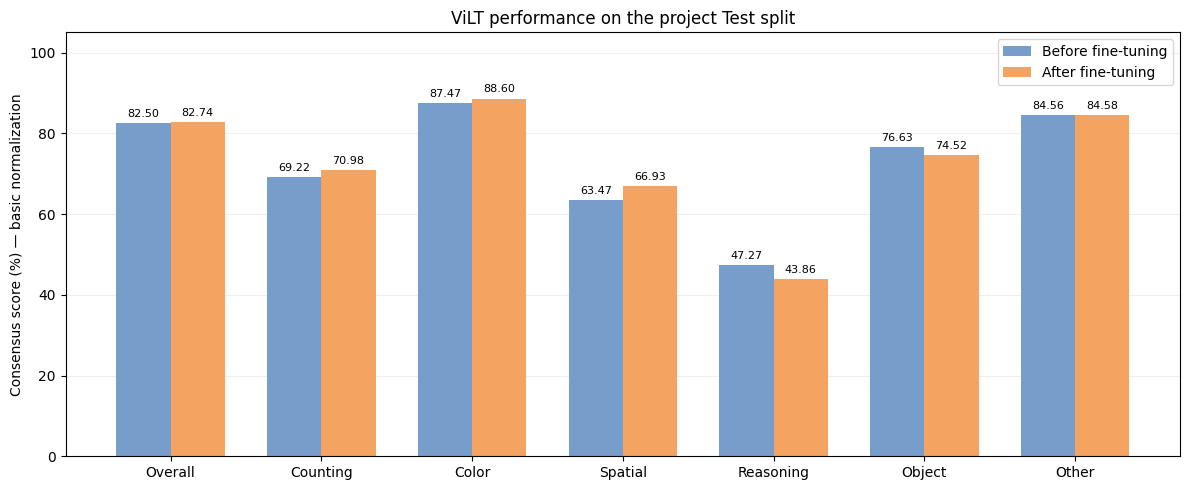

Biểu đồ đã lưu tại: /kaggle/working/results/figures
Thay đổi Consensus tổng thể: +0.24 điểm phần trăm


In [23]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

results_dir = Path("/kaggle/working/results")

categories = [
    "Overall", "Counting", "Color",
    "Spatial", "Reasoning", "Object", "Other"
]

reports = {}
scores = {}

# Đọc kết quả do evaluate.py tạo
for run in ["baseline", "finetuned"]:
    path = results_dir / run / "metrics.json"

    if not path.is_file():
        raise FileNotFoundError(f"Chưa có kết quả đánh giá: {path}")

    report = json.loads(path.read_text(encoding="utf-8"))

    if report["partial_run"]:
        raise ValueError(f"{run} chưa đánh giá toàn bộ tập Test")

    rows = {
        row["category"]: row
        for row in report["metrics"]
    }

    scores[run] = [
        rows[name.lower()]["consensus_basic_pct"]
        for name in categories
    ]

    if any(value is None for value in scores[run]):
        raise ValueError(f"{run} có nhóm câu hỏi chưa có điểm")

    reports[run] = report

# Bảo đảm hai lần đánh giá dùng cùng file Test
if reports["baseline"]["data_sha256"] != reports["finetuned"]["data_sha256"]:
    raise ValueError("Hai kết quả không dùng cùng file Test")

baseline = scores["baseline"]
finetuned = scores["finetuned"]

output_dir = results_dir / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

x = np.arange(len(categories))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 5))

bars_before = ax.bar(
    x - width / 2, baseline, width,
    label="Before fine-tuning", color="#779ECB"
)
bars_after = ax.bar(
    x + width / 2, finetuned, width,
    label="After fine-tuning", color="#F4A460"
)

ax.bar_label(bars_before, fmt="%.2f", padding=3, fontsize=8)
ax.bar_label(bars_after, fmt="%.2f", padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Consensus score (%) — basic normalization")
ax.set_title("ViLT performance on the project Test split")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

fig.tight_layout()

fig.savefig(
    output_dir / "baseline_vs_finetuned.png",
    dpi=300, bbox_inches="tight"
)
fig.savefig(
    output_dir / "baseline_vs_finetuned.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Biểu đồ đã lưu tại:", output_dir)
print(
    "Thay đổi Consensus tổng thể:",
    f"{finetuned[0] - baseline[0]:+.2f} điểm phần trăm"
)

## Thí nghiệm bổ sung: số epoch và learning rate

So sánh ba cấu hình fine-tuning:

- Run A: 1 epoch, learning rate 2e-5 — thí nghiệm chính.
- Run B: 2 epochs, learning rate 2e-5 — kiểm tra ảnh hưởng của việc train lâu hơn.
- Run C: 1 epoch, learning rate 1e-5 — kiểm tra ảnh hưởng của việc giảm learning rate.

Các run dùng cùng dữ liệu, seed 42, batch size 4 và tích lũy
gradient qua 4 batch. Mỗi run khởi tạo từ checkpoint ViLT VQA
ban đầu và lưu kết quả trong thư mục riêng.



### Train B — 2 epochs
Huấn luyện với 2 epochs, learning rate 2e-5 để kiểm tra ảnh hưởng
của việc tăng thời gian huấn luyện.

In [26]:
import subprocess
import sys
from pathlib import Path

train_script = Path(
    "/kaggle/input/datasets/dungnt28/training-codepy/train.py"
)

if not train_script.is_file():
    raise FileNotFoundError(train_script)

subprocess.run(
    [
        sys.executable, str(tra in_script),
        "--model", "dandelin/vilt-b32-finetuned-vqa",
        "--data-dir", "/kaggle/working/vqa_processed",
        "--epochs", "2",
        "--batch-size", "4",
        "--accumulation-steps", "4",
        "--learning-rate", "2e-5",
        "--seed", "42",
        "--output-dir", "/kaggle/working/vilt_run_B",
    ],
    check=True,
)

Train: 50419; Dev: 6684; excluded unsupported Train: 688


Development evaluation: 100%|██████████| 1671/1671 [02:11<00:00, 12.75it/s]


{"epoch": 1, "train_loss": 2.3020244627719895, "dev_exact_match_basic_pct": 71.94793536804309, "dev_consensus_basic_pct": 81.50807899461473}
Best checkpoint saved: /kaggle/working/vilt_run_B/best


Development evaluation: 100%|██████████| 1671/1671 [02:07<00:00, 13.11it/s]


{"epoch": 2, "train_loss": 1.8998291653096138, "dev_exact_match_basic_pct": 72.51645721125075, "dev_consensus_basic_pct": 82.00777977259192}
Best checkpoint saved: /kaggle/working/vilt_run_B/best
Training complete. Test data was not used for selection.


CompletedProcess(args=['/usr/bin/python3', '/kaggle/input/datasets/dungnt28/training-codepy/train.py', '--model', 'dandelin/vilt-b32-finetuned-vqa', '--data-dir', '/kaggle/working/vqa_processed', '--epochs', '2', '--batch-size', '4', '--accumulation-steps', '4', '--learning-rate', '2e-5', '--seed', '42', '--output-dir', '/kaggle/working/vilt_run_B'], returncode=0)

### Đánh giá Run B
Đánh giá checkpoint tốt nhất theo Dev của Run B trên toàn bộ tập Test.
Lưu kết quả tại `results/run_B`.

In [27]:
import subprocess 
import sys
from pathlib import Path

paths = list(Path("/kaggle/input").rglob("evaluate.py"))
if len(paths) != 1:
    raise ValueError(f"Tìm thấy {len(paths)} file evaluate.py")

subprocess.run(
    [
        sys.executable, str(paths[0]),
        "--model", "/kaggle/working/vilt_run_B/best",
        "--data-file", "/kaggle/working/vqa_processed/test.jsonl",
        "--device", "cuda",
        "--batch-size", "8",
        "--output-dir", "/kaggle/working/results/run_B",
    ],
    check=True,
)

Device: cuda:0; evaluation examples: 6125


Evaluation: 100%|██████████| 766/766 [01:57<00:00,  6.54it/s]


overall: n=6125, exact=72.64%, consensus=82.53%
counting: n=580, exact=56.55%, consensus=69.17%
color: n=550, exact=78.73%, consensus=88.04%
spatial: n=101, exact=53.47%, consensus=67.03%
reasoning: n=44, exact=38.64%, consensus=44.55%
object: n=199, exact=66.33%, consensus=74.17%
other: n=4651, exact=74.93%, consensus=84.59%
Results saved to: /kaggle/working/results/run_B


CompletedProcess(args=['/usr/bin/python3', '/kaggle/input/datasets/dungnt28/evaluate/evaluate.py', '--model', '/kaggle/working/vilt_run_B/best', '--data-file', '/kaggle/working/vqa_processed/test.jsonl', '--device', 'cuda', '--batch-size', '8', '--output-dir', '/kaggle/working/results/run_B'], returncode=0)

### Train C — Learning rate 1e-5
Huấn luyện 1 epoch với learning rate 1e-5 để kiểm tra ảnh hưởng
của việc giảm learning rate.

In [29]:
import subprocess 
import sys
from pathlib import Path

train_script = Path(
    "/kaggle/input/datasets/dungnt28/training-codepy/train.py"
)

if not train_script.is_file():
    raise FileNotFoundError(train_script)

subprocess.run(
    [
        sys.executable, str(train_script),
        "--model", "dandelin/vilt-b32-finetuned-vqa",
        "--data-dir", "/kaggle/working/vqa_processed",
        "--epochs", "1",
        "--batch-size", "4",
        "--accumulation-steps", "4",
        "--learning-rate", "1e-5",
        "--seed", "42",
        "--output-dir", "/kaggle/working/vilt_run_C",
    ],
    check=True,
)

Train: 50419; Dev: 6684; excluded unsupported Train: 688


Development evaluation: 100%|██████████| 1671/1671 [02:10<00:00, 12.85it/s]


{"epoch": 1, "train_loss": 2.2682104632256936, "dev_exact_match_basic_pct": 73.09994015559545, "dev_consensus_basic_pct": 82.61220825852847}
Best checkpoint saved: /kaggle/working/vilt_run_C/best
Training complete. Test data was not used for selection.


CompletedProcess(args=['/usr/bin/python3', '/kaggle/input/datasets/dungnt28/training-codepy/train.py', '--model', 'dandelin/vilt-b32-finetuned-vqa', '--data-dir', '/kaggle/working/vqa_processed', '--epochs', '1', '--batch-size', '4', '--accumulation-steps', '4', '--learning-rate', '1e-5', '--seed', '42', '--output-dir', '/kaggle/working/vilt_run_C'], returncode=0)

### Đánh giá Run C
Đánh giá checkpoint tốt nhất theo Dev của Run C trên toàn bộ tập Test.
Lưu kết quả tại `results/run_C`.

In [31]:
import subprocess 
import sys
from pathlib import Path

paths = list(Path("/kaggle/input").rglob("evaluate.py"))
if len(paths) != 1:
    raise ValueError(f"Tìm thấy {len(paths)} file evaluate.py")

subprocess.run(
    [
        sys.executable, str(paths[0]),
        "--model", "/kaggle/working/vilt_run_C/best",
        "--data-file", "/kaggle/working/vqa_processed/test.jsonl",
        "--device", "cuda",
        "--batch-size", "8",
        "--output-dir", "/kaggle/working/results/run_C",
    ],
    check=True,
)

Device: cuda:0; evaluation examples: 6125


Evaluation: 100%|██████████| 766/766 [01:57<00:00,  6.50it/s]


overall: n=6125, exact=73.67%, consensus=83.13%
counting: n=580, exact=58.45%, consensus=70.98%
color: n=550, exact=79.45%, consensus=88.60%
spatial: n=101, exact=54.46%, consensus=67.33%
reasoning: n=44, exact=40.91%, consensus=45.91%
object: n=199, exact=66.83%, consensus=75.08%
other: n=4651, exact=75.90%, consensus=85.03%
Results saved to: /kaggle/working/results/run_C


CompletedProcess(args=['/usr/bin/python3', '/kaggle/input/datasets/dungnt28/evaluate/evaluate.py', '--model', '/kaggle/working/vilt_run_C/best', '--data-file', '/kaggle/working/vqa_processed/test.jsonl', '--device', 'cuda', '--batch-size', '8', '--output-dir', '/kaggle/working/results/run_C'], returncode=0)

## 7. Lưu và chia sẻ kết quả

### 7.1. Tạo các file ZIP sao lưu

Đóng gói kết quả trong `/kaggle/working` thành ba file:

- vilt_finetuned_backup.zip: checkpoint, cấu hình và lịch sử training.
- experiment_results.zip: kết quả baseline, fine-tune và biểu đồ
  nếu đã tạo trong thư mục results.
- prepared_data.zip: dữ liệu JSONL và thông tin chuẩn bị dữ liệu,
  không chứa ảnh gốc.

Nếu thư mục nguồn chưa tồn tại, ô sẽ thông báo “Chưa có”.
Chạy lại sẽ ghi đè các ZIP cùng tên bằng nội dung hiện tại.

Sau khi tạo ZIP, Save Version với lưu output được bật.
Tải file từ tab Output của phiên bản đã lưu nếu link dưới ô bị lỗi.



In [32]:
import shutil
from pathlib import Path
from IPython.display import FileLink, display

working = Path("/kaggle/working")

packages = [
    ("vilt_finetuned_backup", working / "vilt_finetuned"),
    ("experiment_results", working / "results"),
    ("prepared_data", working / "vqa_processed"),
]

for name, source in packages:
    if source.exists():
        archive = shutil.make_archive(
            str(working / name), "zip", str(source)
        )
        display(FileLink(archive))
    else:
        print("Chưa có:", source)

/kaggle/working/vilt_finetuned_backup.zip

/kaggle/working/experiment_results.zip

/kaggle/working/prepared_data.zip

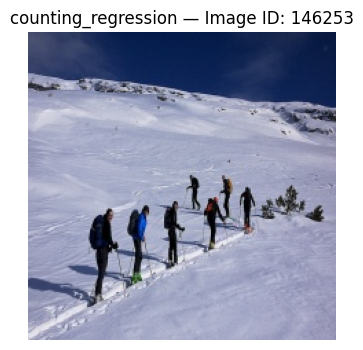

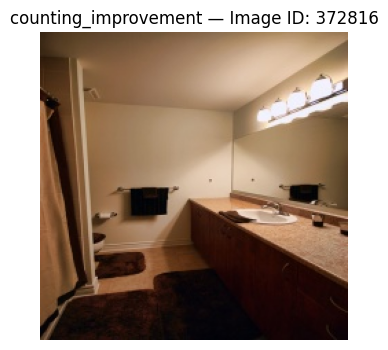

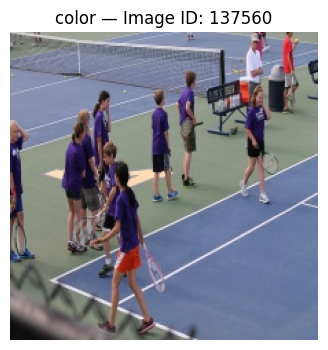

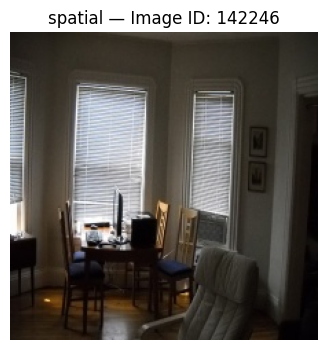

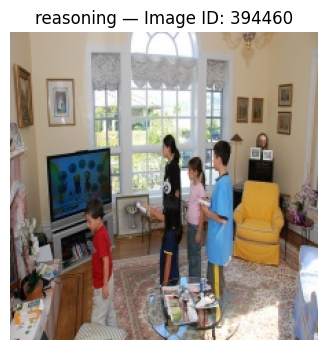

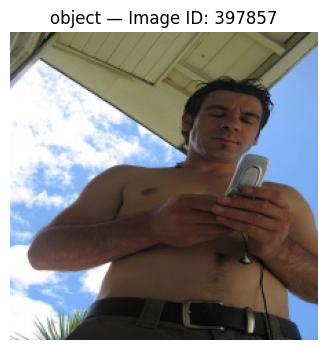

Ảnh đã lưu tại: /kaggle/working/results/error_analysis


In [2]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Thư mục ảnh gốc
image_dir = Path(
    "/kaggle/input/datasets/henrychibueze/vqa-dataset/val2014-resised"
)

# Sáu ảnh tương ứng với các case đã kiểm tra
cases = [
    ("counting_regression", 146253),
    ("counting_improvement", 372816),
    ("color", 137560),
    ("spatial", 142246),
    ("reasoning", 394460),
    ("object", 397857),
]

# Thư mục lưu ảnh cho báo cáo
output_dir = Path("/kaggle/working/results/error_analysis")
output_dir.mkdir(parents=True, exist_ok=True)

for name, image_id in cases:
    filename = f"COCO_val2014_{image_id:012d}.jpg"
    image_path = image_dir / filename

    if not image_path.exists():
        print("Không tìm thấy:", image_path)
        continue

    with Image.open(image_path) as source:
        image = source.convert("RGB")

    image.save(output_dir / f"{name}.png")

    plt.figure(figsize=(6, 4))
    plt.imshow(image)
    plt.title(f"{name} — Image ID: {image_id}")
    plt.axis("off")
    plt.show()
    plt.close()

print("Ảnh đã lưu tại:", output_dir)

Lấy ảnh demo cho report
